In [ ]:
import pickle
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm

from src.modules.generate_ecg import generate_ecg
from src.modules.subfunctions import SimulationParameters

warnings.filterwarnings("ignore")

LINE_WIDTH = 2
ALPHA = 0.15
# %matplotlib tk

<frozen importlib._bootstrap>:491: RuntimeWarning: The global interpreter lock (GIL) has been enabled to load module 'fontTools.misc.bezierTools', which has not declared that it can run safely without the GIL. To override this behavior and keep the GIL disabled (at your own risk), run with PYTHON_GIL=0 or -Xgil=0.


In [2]:
data_plot = defaultdict(dict)

with open("y_data_3_small.pkl", "rb") as file:
    data_plot["y_data_3_small"] = pickle.load(file)

with open("y_data_4_small.pkl", "rb") as file:
    data_plot["y_data_4_small"] = pickle.load(file)

with open("y_data_5_small.pkl", "rb") as file:
    data_plot["y_data_5_small"] = pickle.load(file)

with open("y_data_6_small.pkl", "rb") as file:
    data_plot["y_data_6_small"] = pickle.load(file)

with open("y_data_7_small.pkl", "rb") as file:
    data_plot["y_data_7_small"] = pickle.load(file)

with open("y_data_8_small.pkl", "rb") as file:
    data_plot["y_data_8_small"] = pickle.load(file)

with open("y_data_mov_3_small.pkl", "rb") as file:
    data_plot["y_data_mov_3_small"] = pickle.load(file)

with open("y_data_mov_4_small.pkl", "rb") as file:
    data_plot["y_data_mov_4_small"] = pickle.load(file)

with open("y_data_mov_5_small.pkl", "rb") as file:
    data_plot["y_data_mov_5_small"] = pickle.load(file)

with open("y_data_3.pkl", "rb") as file:
    data_plot["y_data_3_big"] = pickle.load(file)

with open("y_data_4.pkl", "rb") as file:
    data_plot["y_data_4_big"] = pickle.load(file)

with open("y_data_mov_3.pkl", "rb") as file:
    data_plot["y_data_mov_3_big"] = pickle.load(file)

with open("y_data_mov_4.pkl", "rb") as file:
    data_plot["y_data_mov_4_big"] = pickle.load(file)

with open("y_data_mov_5.pkl", "rb") as file:
    data_plot["y_data_5_big"] = pickle.load(file)

with open("y_data_mov_6.pkl", "rb") as file:
    data_plot["y_data_6_big"] = pickle.load(file)

In [3]:
R_CHEST = 0.35
R_HIPS = 0.4
R_BELLY = 0.1
A = 8.0
C = 6.0
V0 = -0.1
W = 0.3

u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(-0.5, 0.5, 120)
u, v = np.meshgrid(u, v)

R_base = R_CHEST * np.exp(-A * (v - 0.3) ** 2) + R_HIPS * np.exp(-C * (v + 0.3) ** 2)

belly_profile = 1 / (1 + ((v - V0) / W) ** 4)
front = np.maximum(0, np.cos(u))

belly = R_BELLY * belly_profile * front

R = R_base + belly

x = R * np.cos(u)
x += 0.1 * np.exp(-10 * (v - V0) ** 2)
y = R * np.sin(u)
z = v

In [4]:
N_PHI_HEARTS_LEFT = 7
N_PHI_HEARTS_RIGHT = 4
N_Z_HEARTS = 4
N_R = 2
phi_left_hearts = np.linspace(0, 5 * np.pi / 18, N_PHI_HEARTS_LEFT)
phi_right_hearts = np.linspace(-np.pi / 17, -np.pi / 4, N_PHI_HEARTS_RIGHT)
phi_hearts = np.concatenate([phi_left_hearts, phi_right_hearts])
z_low_hearts = np.linspace(-0.35, -0.07, N_Z_HEARTS)
z_high_hearts = np.array([0, 0.025, 0.04])
z_lin_hearts = np.concatenate([z_low_hearts, z_high_hearts])

d_vals = np.linspace(0.04, 0.11, N_R)
phi_3d, z_3d, d_3d = np.meshgrid(phi_hearts, z_lin_hearts, d_vals, indexing="ij")
R_base_pts = R_CHEST * np.exp(-A * (z_3d - 0.3) ** 2) + R_HIPS * np.exp(
    -C * (z_3d + 0.3) ** 2
)

belly_profile_pts = 1 / (1 + ((z_3d - V0) / W) ** 4)
front_pts = np.maximum(0, np.cos(phi_3d))
belly_pts = R_BELLY * belly_profile_pts * front_pts

R_surface = R_base_pts + belly_pts

R_inner = R_surface - d_3d

R_inner = np.maximum(R_inner, 0)

x_center = 0.1 * np.exp(-10 * (z_3d - V0) ** 2)

x_inner = x_center + R_inner * np.cos(phi_3d)
y_inner = R_inner * np.sin(phi_3d)
z_inner = z_3d
phi_flat = phi_3d.flatten()
R_flat = R_inner.flatten()
z_flat = z_3d.flatten()
points_inner_cyl = np.column_stack((phi_flat, R_flat, z_flat))

In [5]:
params_small = {
    "N_PHI_PTS_LEFT": 4,
    "N_PHI_PTS_RIGHT": 3,
    "N_Z_PTS": 2,
    "z_low_pts": np.linspace(-0.4, -0.25, 2),
    "z_high_pts": np.array([-0.1, 0.05]),
}

params_big = {
    "N_PHI_PTS_LEFT": 6,
    "N_PHI_PTS_RIGHT": 4,
    "N_Z_PTS": 3,
    "z_low_pts": np.linspace(-0.4, -0.1, 3),
    "z_high_pts": np.array([0, 0.1]),
}


def compute_points_cyl(
    N_PHI_PTS_LEFT,
    N_PHI_PTS_RIGHT,
    N_Z_PTS,
    z_low_pts,
    z_high_pts,
    R_CHEST,
    A,
    R_HIPS,
    C,
    V0,
    W,
    R_BELLY,
):
    z_lin_pts = np.concatenate([z_low_pts, z_high_pts])

    phi_left_pts = np.linspace(0, np.pi / 3, N_PHI_PTS_LEFT)
    phi_right_pts = np.linspace(-np.pi / 3.5, -np.pi / 12, N_PHI_PTS_RIGHT)
    phi_pts = np.concatenate([phi_left_pts, phi_right_pts])

    phi_pts, z_lin_pts = np.meshgrid(phi_pts, z_lin_pts)

    R_base_pts = R_CHEST * np.exp(-A * (z_lin_pts - 0.3) ** 2) + R_HIPS * np.exp(
        -C * (z_lin_pts + 0.3) ** 2
    )

    belly_profile_pts = 1 / (1 + ((z_lin_pts - V0) / W) ** 4)
    front_pts = np.maximum(0, np.cos(phi_pts))
    belly_pts = R_BELLY * belly_profile_pts * front_pts

    R_pts = R_base_pts + belly_pts

    x_pts = R_pts * np.cos(phi_pts)
    x_pts += 0.1 * np.exp(-10 * (z_lin_pts - V0) ** 2)
    y_pts = R_pts * np.sin(phi_pts)

    R_true = np.sqrt(x_pts**2 + y_pts**2)
    phi_true = np.arctan2(y_pts, x_pts)

    phi_flat = phi_true.flatten()
    r_flat = R_true.flatten()
    z_flat = z_lin_pts.flatten()
    points_cyl = np.column_stack((phi_flat, r_flat, z_flat))

    return points_cyl


points_cyl_small = compute_points_cyl(
    **params_small,
    R_CHEST=R_CHEST,
    A=A,
    R_HIPS=R_HIPS,
    C=C,
    V0=V0,
    W=W,
    R_BELLY=R_BELLY,
)

points_cyl_big = compute_points_cyl(
    **params_big, R_CHEST=R_CHEST, A=A, R_HIPS=R_HIPS, C=C, V0=V0, W=W, R_BELLY=R_BELLY
)

In [6]:
FS = 200
TIME = 20
all_mix_small = []
all_fecg_small = []
all_mix_big = []
all_fecg_big = []

for foetus in tqdm(range(points_inner_cyl.shape[0]), desc="Foetus generation"):
    params_small = SimulationParameters(
        elpos=points_cyl_small,
        fheart=[points_inner_cyl[foetus]],
        ntype=np.array([""]),
        SNRmn=6,
        fs=FS,
        n=FS * TIME,
        ftraj=np.array(["none"]),
    )
    out_small = generate_ecg(params_small).to_dict()
    all_mix_small.append(out_small["mixture"])
    all_fecg_small.append(out_small["fecg"][0])
    params_big = SimulationParameters(
        elpos=points_cyl_big,
        fheart=[points_inner_cyl[foetus]],
        ntype=np.array([""]),
        SNRmn=6,
        fs=FS,
        n=FS * TIME,
        ftraj=np.array(["none"]),
    )
    out_big = generate_ecg(params_big).to_dict()
    all_mix_big.append(out_big["mixture"])
    all_fecg_big.append(out_big["fecg"][0])

Foetus generation: 100%|██████████| 154/154 [01:16<00:00,  2.01it/s]


In [7]:
def signal_fraction(mix, fecg):
    x = mix - np.mean(mix)
    s = fecg - np.mean(fecg)
    a = np.dot(x, s) / np.dot(s, s)
    cov_xy = np.mean(x * s)
    var_x = np.var(x)
    var_s = np.var(s)
    if var_x == 0 or var_s == 0:
        fraction = 1.0 if np.allclose(x, a * s) else 0
    else:
        r2 = (cov_xy**2) / (var_x * var_s)
        fraction = max(0.0, min(1.0, r2))

    return np.float32(fraction)


def pol2cart(rho, phi, z=None):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    if z is not None:
        return x, y, z
    return x, y

In [ ]:
def create_pdf(el_conf, name, mode):
    x_plot = np.linspace(0, 20, 20 * 200)
    with PdfPages(f"{name}_{mode}.pdf") as pdf:
        num_items = points_inner_cyl.shape[0]
        num_subitems = len(el_conf) - 1
        for item_idx in tqdm(range(num_items), leave=False):
            fig = plt.figure(figsize=(17, 10))
            gs = fig.add_gridspec(num_subitems, 2, width_ratios=[1, 1.5])
            fecg = all_fecg_big[item_idx][el_conf]
            mix = all_mix_big[item_idx][el_conf]

            diff = mix[:-1] - mix[-1]
            metric = np.array(
                [signal_fraction(diff[i], fecg[i]) for i in range(num_subitems)]
            )
            fig.suptitle(
                f"Foetus {item_idx + 1}, metric = {np.max(metric):.2g}",
                fontsize=16,
                fontweight="bold",
            )
            for sub_idx in range(num_subitems):
                ax = fig.add_subplot(gs[sub_idx, 0])
                ax.plot(
                    x_plot,
                    diff[sub_idx],
                    color="r",
                    linewidth=2,
                    label="signal on electrode",
                )
                ax.plot(x_plot, fecg[sub_idx], color="k", linewidth=2, label="fecg")
                ax.set_title(
                    f"Active electrode {sub_idx + 1}, metric = {metric[sub_idx]:.2g}"
                )
                ax.set_ylabel("Values")

                ax.grid(True, linestyle="--")
                ax.set_xlim(0, 5)

            ax_3d = fig.add_subplot(gs[:, 1], projection="3d")
            ax_3d.plot_surface(x, y, z, alpha=ALPHA)
            x_heart, y_heart = pol2cart(
                points_inner_cyl[item_idx][1], points_inner_cyl[item_idx][0]
            )
            ax_3d.scatter(
                x_heart, y_heart, points_inner_cyl[item_idx][-1], s=7, color="k"
            )
            x_big, y_big, z_big = pol2cart(
                points_cyl_big.T[1][el_conf],
                points_cyl_big.T[0][el_conf],
                points_cyl_big.T[2][el_conf],
            )
            for index in range(len(x_big)):
                ax_3d.scatter(
                    x_big[index],
                    y_big[index],
                    z_big[index],
                    s=150,
                    marker=f"${index + 1}$",
                    color="r",
                )
            ax_3d.view_init(elev=0, azim=0, roll=0)
            ax.set_xlabel("Time, s")
            handles, labels = [], []
            for ax in fig.axes:
                h, l = ax.get_legend_handles_labels()
                handles.extend(h)
                labels.extend(l)
            unique_labels_handles = dict(zip(labels, handles))
            fig.legend(unique_labels_handles.values(), unique_labels_handles.keys())
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

In [ ]:
for electrode_data in tqdm(list(data_plot.keys())[:-1]):
    el_config = max(data_plot[electrode_data])[1]
    create_pdf(el_config, electrode_data, "max")
    el_config = min(data_plot[electrode_data])[1]
    create_pdf(el_config, electrode_data, "min")

100%|██████████| 1/1 [01:48<00:00, 108.74s/it]


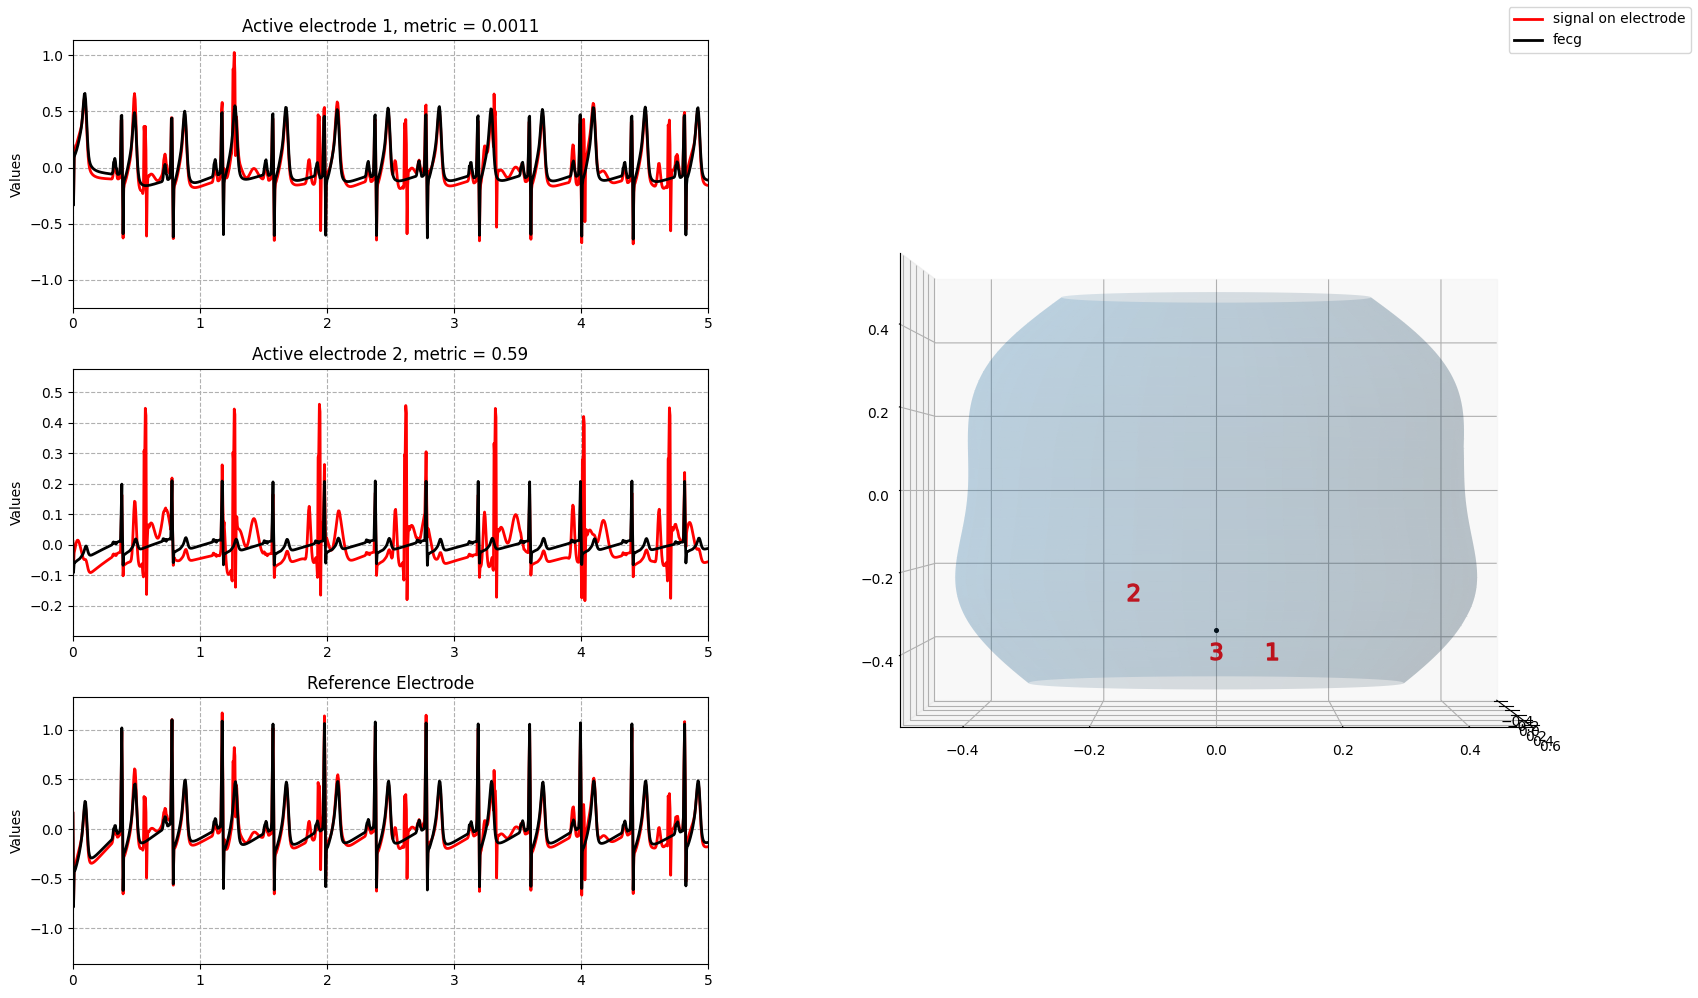

In [ ]:
test = max(data_plot["y_data_3_small"])
item_idx = 1
num_subitems = len(test[1])
x_plot = np.linspace(0, 20, 20 * 200)
fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(num_subitems, 2, width_ratios=[1, 1.5])
fecg = all_fecg_big[item_idx][test[1]]
mix = all_mix_big[item_idx][test[1]]

diff = mix[:-1] - mix[-1]
metric = np.array([signal_fraction(diff[i], fecg[i]) for i in range(num_subitems - 1)])
for sub_idx in range(num_subitems):
    ax = fig.add_subplot(gs[sub_idx, 0])
    ax.plot(x_plot, mix[sub_idx], color="r", linewidth=2, label="signal on electrode")
    ax.plot(x_plot, fecg[sub_idx], color="k", linewidth=2, label="fecg")
    ax.set_xlim(0, 5)
    if sub_idx == num_subitems - 1:
        ax.set_title(f"Reference Electrode")
        ax.set_ylabel("Values")
        ax.grid(True, linestyle="--")
    else:
        ax.set_title(f"Active electrode {sub_idx + 1}, metric = {metric[sub_idx]:.2g}")
        ax.set_ylabel("Values")

        ax.grid(True, linestyle="--")

ax_3d = fig.add_subplot(gs[:, 1], projection="3d")
ax_3d.plot_surface(x, y, z, alpha=ALPHA)
x_heart, y_heart = pol2cart(
    points_inner_cyl[item_idx][1], points_inner_cyl[item_idx][0]
)
ax_3d.scatter(x_heart, y_heart, points_inner_cyl[item_idx][-1], s=7, color="k")
x_big, y_big, z_big = pol2cart(
    points_cyl_big.T[1][test[1]],
    points_cyl_big.T[0][test[1]],
    points_cyl_big.T[2][test[1]],
)
for index in range(len(x_big)):
    ax_3d.scatter(
        x_big[index],
        y_big[index],
        z_big[index],
        s=150,
        marker=f"${index + 1}$",
        color="r",
    )


ax_3d.view_init(elev=0, azim=0, roll=0)
handles, labels = [], []
for ax in fig.axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# 2. Use a dict comprehension to keep only unique labels
unique_labels_handles = dict(zip(labels, handles))

# 3. Create a single, clean figure-level legend
fig.legend(unique_labels_handles.values(), unique_labels_handles.keys())
# Автоматически настраиваем отступы, чтобы подписи не наезжали друг на друга
plt.tight_layout()
plt.show()